In [ ]:
# 先按照mujoco playground的教程安装好环境，mujoco playground结合了madrona高性能并行渲染
# 之前做仿真器优化时使用的, rollout视频生成加速，不过最后也没搞出来
import os
import functools
import jax
import jax.numpy as jp
import numpy as np
import mediapy as media
from flax import linen
from brax.io import model

from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import networks_vision

from mujoco_playground import manipulation
from mujoco_playground import wrapper
from mujoco_playground._src.manipulation.franka_emika_panda import randomize_vision as randomize

# 1. 设置环境变量
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false" # 是否预分配所有GPU内存，设置为false可以按需分配，避免占满所有内存
# def limit_jax_mem(limit):
#   os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = f"{limit:.2f}"
# limit_jax_mem(0.6)
os.environ['MUJOCO_GL']="egl"


In [2]:
# 2. 配置参数
num_envs = 1024
print(f"并行环境数量为: {num_envs}")

env_name = "PandaPickCubeCartesian"
env_cfg = manipulation.get_default_config(env_name)
episode_length = int(4 / env_cfg.ctrl_dt) #渲染4s

# 配置必须与训练时一致，除了 render_batch_size
config_overrides = {
    "episode_length": episode_length,
    "vision": True,
    "obs_noise.brightness": [0.75, 2.0],
    "vision_config.use_rasterizer": False, #raytracer需要编译madrona，rasterizer使用的vulkan
    "vision_config.render_batch_size": num_envs, # 这里改成 64
    "vision_config.render_width": 128,
    "vision_config.render_height": 128,
    "box_init_range": 0.1,
    "action_history_length": 5,
    "success_threshold": 0.03
}

# 3. 加载环境
env = manipulation.load(env_name, config=env_cfg, config_overrides=config_overrides)

randomization_fn = functools.partial(randomize.domain_randomize, num_worlds=num_envs)

env = wrapper.wrap_for_brax_training(
    env,
    vision=True,
    num_vision_envs=num_envs,
    episode_length=episode_length,
    action_repeat=1,
    randomization_fn=randomization_fn
)

设置环境数量为: 1024
Using raytracer
Compiling /home/wzb/ideas/simu/madrona_mjx/external/madrona/src/mw/device/bvh.cpp
Compiling /home/wzb/ideas/simu/madrona_mjx/external/madrona/src/mw/device/memory.cpp
Compiling /home/wzb/ideas/simu/madrona_mjx/external/madrona/src/mw/device/host_print.cpp
Compiling /home/wzb/ideas/simu/madrona_mjx/external/madrona/src/mw/device/bvh_raycast.cpp
Compiling GPU engine code:
Initialization finished


/home/wzb/miniconda3/envs/mujplay/targets/x86_64-linux/include/cub/warp/warp_scan.cuh(179): warning #1444-D: member "cub::CUB_200802_SM_900::BaseTraits<cub::CUB_200802_SM_900::SIGNED_INTEGER, true, false, _UnsignedBits, T>::CATEGORY [with _UnsignedBits=unsigned int, T=int]" was declared deprecated ("Use <cuda/std/type_traits> instead")
      IS_INTEGER = ((Traits<T>::CATEGORY == SIGNED_INTEGER) || (Traits<T>::CATEGORY == UNSIGNED_INTEGER))
                                ^
/home/wzb/miniconda3/envs/mujplay/targets/x86_64-linux/include/cub/util_type.cuh(878): note #3287-D: because of a "deprecated" attribute
    CCCL_DEPRECATED_BECAUSE("Use <cuda/std/type_traits> instead") static constexpr Category CATEGORY = SIGNED_INTEGER;
    ^
          detected during:
            instantiation of class "cub::CUB_200802_SM_900::WarpScan<T, LOGICAL_WARP_THREADS, LEGACY_PTX_ARCH> [with T=int, LOGICAL_WARP_THREADS=32, LEGACY_PTX_ARCH=0]" at line 117 of /home/wzb/miniconda3/envs/mujplay/targets/x86_64-

In [3]:
# 4. 重建网络
network_factory = functools.partial(
    networks_vision.make_ppo_networks_vision, 
    policy_hidden_layer_sizes=[256, 256],
    value_hidden_layer_sizes=[256, 256],
    activation=linen.relu,
    normalise_channels=True
)

# 5. 加载参数
model_path = "panda_ppo_params.pkl"
if not os.path.exists(model_path):
    raise FileNotFoundError(f"找不到模型文件: {model_path}")
params = model.load_params(model_path)

In [4]:
# 6. 构建推理函数
ppo_network_instance = network_factory(env.observation_size, env.action_size)
make_inference_fn_builder = ppo_networks.make_inference_fn(ppo_network_instance)

# 开启 deterministic=True 以获得稳定表现
inference_fn_single = make_inference_fn_builder(params, deterministic=True)
# 使用 vmap 支持 batch (64/256等等环境)
inference_fn = jax.jit(jax.vmap(inference_fn_single))

jit_reset = jax.jit(env.reset)
jit_step = jax.jit(env.step)

def tile(img, d):
    assert img.shape[0] == d*d
    img = img.reshape((d,d)+img.shape[1:])
    return np.concat(np.concat(img, axis=1), axis=1)

def unvmap(x):
    return jax.tree.map(lambda y: y[0], x)

# 8. 运行 Rollout (只收集数据，不渲染)
print(f"开始运行 Rollout ({episode_length} steps)...")

rng = jax.random.PRNGKey(0)
rng, reset_rng = jax.random.split(rng)
reset_keys = jax.random.split(reset_rng, num_envs) # Shape (64, 2)

state = jit_reset(reset_keys)
rollout = [] # 用于存储每一帧的 state

# 预热
rng, act_rng = jax.random.split(rng)
act_keys = jax.random.split(act_rng, num_envs)
act, _ = inference_fn(state.obs, act_keys)
_ = jit_step(state, act)

# 正式循环
to_keep = 256
rollout = [] # 用于存储每一帧的 state

def keep_until(state, i):
    return jax.tree.map(lambda x: x[:i], state) #state里有许多中数据，每个都是envs维度，但是不能直接切片，这个就是来切片的

for i in range(episode_length):
    rng, act_rng = jax.random.split(rng)
    act_keys = jax.random.split(act_rng, num_envs)
    action, _ = inference_fn(state.obs, act_keys)
    state = jit_step(state, action)
    rollout.append(keep_until(state, to_keep))
    
    if (i+1) % 10 == 0:
        print(f"Step {i+1}/{episode_length}")
        

开始运行 Rollout (80 steps)...


/home/wzb/miniconda3/envs/mujplay/lib/python3.11/site-packages/jax/_src/interpreters/xla.py:132: RuntimeWarning: overflow encountered in cast
  return np.asarray(x, dtypes.canonicalize_dtype(x.dtype))


Step 10/80
Step 20/80
Step 30/80
Step 40/80
Step 50/80
Step 60/80
Step 70/80
Step 80/80


In [5]:
#服务器图形化时我一般用mobaxterm连接，mobaxterm自带X server，设置好了DISPLAY=localhost:10.0
os.environ["DISPLAY"] = "localhost:10.0" 
render_every = 1
frames = env.render([unvmap(s) for s in rollout][::render_every])

import imageio
imageio.mimsave("rollout.mp4", frames, fps=int(1.0 / env.dt), macro_block_size=None)

# 9. 后处理与生成视频
obs_frames = []

for i, s in enumerate(rollout):
    # 获取当前步所有环境的图像
    pixels = s.obs['pixels/view_0']
    if pixels.dtype != np.uint8:
        pixels = (pixels * 255).astype(np.uint8)
    obs_frames.append(pixels)

# 拼接图像 grid_size = 16 (因为 num_envs=256)
tiled_frames = [tile(frm, 16) for frm in obs_frames]

output_video = "grid_eval_panda.mp4"
fps = int(1.0 / env_cfg.ctrl_dt)

media.write_video(output_video, tiled_frames, fps=fps)

100%|██████████| 80/80 [00:08<00:00,  9.41it/s]
/home/wzb/miniconda3/envs/mujplay/lib/python3.11/subprocess.py:1885: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _fork_exec(


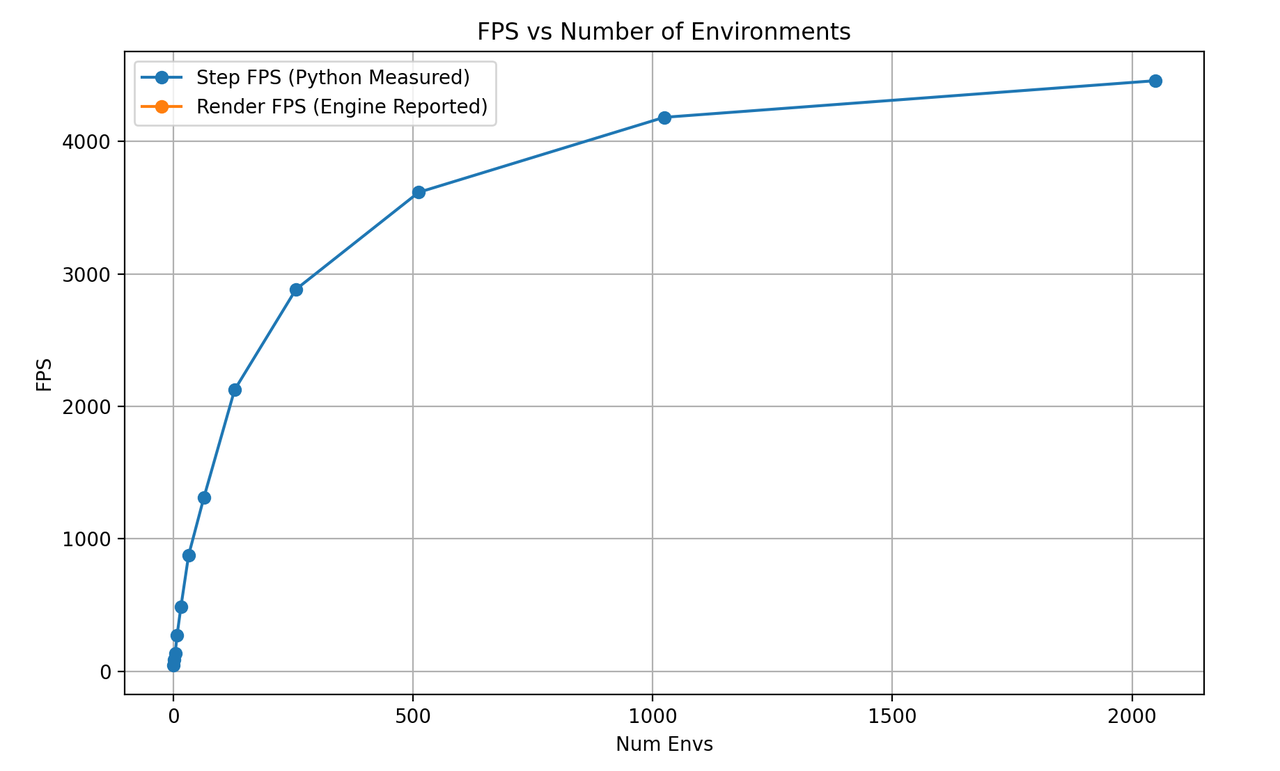

In [ ]:
# H200上的测试结果
from IPython.display import Image
Image(filename="assets/raster.png")

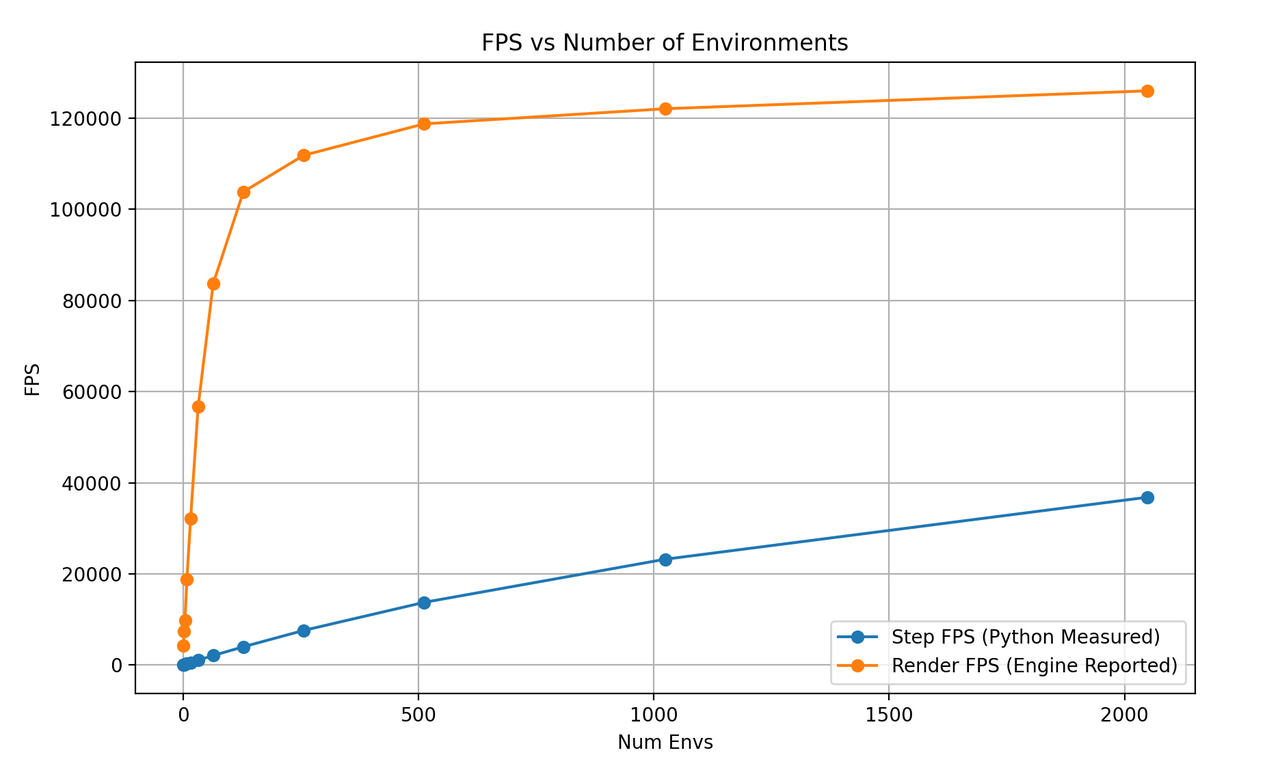

In [4]:
Image(filename="assets/raytracing.png")